# Revision Class 24th March (Revision 2)


## Learning Outcomes
- Use lists, dictionaries, and functions to build clean, reusable Python logic.
- Create, inspect, filter, and summarize DataFrames for practical analysis tasks.
- Build and interpret Seaborn plots (count, scatter, and multiple heatmaps) using Titanic and car data.
- Detect patterns such as correlation and missing values before deeper modeling.
- Perform end-to-end file handling: create CSV, import CSV, append rows, save, and reload.
- Write and explain core SQL queries in text format, including simple filters, JOIN, HAVING, and ORDER BY.

## Part A: Python + Pandas + Seaborn


In [15]:
# Q1: How can we combine list and dictionary logic to make a compact student score report?
students = ['Aarav', 'Diya', 'Kabir', 'Sara', 'Aarav', 'Kabir']
scores = {'Aarav': 78, 'Diya': 92, 'Kabir': 85, 'Sara': 88}

unique_students = sorted(set(students))

report = [{"name": s, "score": scores.get(s, 0), "status": 'Pass' if scores.get(s, 0) >= 80 else 'Needs Work'} for s in unique_students]

print('students:', students)
print('Unique students:', unique_students)
print('Score report:', report)

students: ['Aarav', 'Diya', 'Kabir', 'Sara', 'Aarav', 'Kabir']
Unique students: ['Aarav', 'Diya', 'Kabir', 'Sara']
Score report: [{'name': 'Aarav', 'score': 78, 'status': 'Needs Work'}, {'name': 'Diya', 'score': 92, 'status': 'Pass'}, {'name': 'Kabir', 'score': 85, 'status': 'Pass'}, {'name': 'Sara', 'score': 88, 'status': 'Pass'}]


This combines list cleanup (`set`) with dictionary lookup (`get`) in one practical workflow.
List-comprehension helps produce a structured report quickly for revision and interview-style questions.

In [2]:
# Q2: How do we use functions and modularity to avoid repeating grading logic?
def grade_bucket(score):
    if score >= 90:
        return 'A'
    if score >= 80:
        return 'B'
    if score >= 70:
        return 'C'
    return 'D'

def summarize_scores(score_map):
    output = []
    for name, score in score_map.items():
        output.append((name, score, grade_bucket(score)))
    return sorted(output, key=lambda x: x[1], reverse=True)

summary = summarize_scores({'Aarav': 78, 'Diya': 92, 'Kabir': 85, 'Sara': 88})
print(summary)

[('Diya', 92, 'A'), ('Sara', 88, 'B'), ('Kabir', 85, 'B'), ('Aarav', 78, 'C')]


In [16]:
d={'Aarav': 78, 'Diya': 92, 'Kabir': 85, 'Sara': 88}
d.items()

dict_items([('Aarav', 78), ('Diya', 92), ('Kabir', 85), ('Sara', 88)])

Splitting logic into functions makes code reusable and easier to test in exam questions.
This is a clean example of modular design: one function computes grade, another handles report building.

In [17]:
# Q3: How do we create and inspect a practical car-price DataFrame from scratch?
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
sns.set(style='whitegrid')

car_data = {
    'car_name': ['Swift', 'i20', 'City', 'Creta', 'Baleno', 'Verna', 'Nexon', 'Venue', 'Amaze', 'Seltos'],
    'brand': ['Maruti', 'Hyundai', 'Honda', 'Hyundai', 'Maruti', 'Hyundai', 'Tata', 'Hyundai', 'Honda', 'Kia'],
    'fuel_type': ['Petrol', 'Petrol', 'Petrol', 'Diesel', 'Petrol', 'Diesel', 'Petrol', 'Diesel', 'Petrol', 'Diesel'],
    'engine_cc': [1197, 1197, 1498, 1493, 1197, 1497, 1199, 1493, 1199, 1493],
    'mileage_kmpl': [22.4, 20.3, 17.8, 19.7, 22.9, 20.6, 18.5, 20.1, 18.6, 19.8],
    'price_lakh': [6.2, 7.8, 12.1, 14.5, 7.4, 13.9, 9.2, 12.8, 8.7, 15.2]
}
cars_df = pd.DataFrame(car_data)
print(cars_df)
print('\nShape:', cars_df.shape)
print('\nDtypes:\n', cars_df.dtypes)

  car_name    brand fuel_type  engine_cc  mileage_kmpl  price_lakh
0    Swift   Maruti    Petrol       1197          22.4         6.2
1      i20  Hyundai    Petrol       1197          20.3         7.8
2     City    Honda    Petrol       1498          17.8        12.1
3    Creta  Hyundai    Diesel       1493          19.7        14.5
4   Baleno   Maruti    Petrol       1197          22.9         7.4
5    Verna  Hyundai    Diesel       1497          20.6        13.9
6    Nexon     Tata    Petrol       1199          18.5         9.2
7    Venue  Hyundai    Diesel       1493          20.1        12.8
8    Amaze    Honda    Petrol       1199          18.6         8.7
9   Seltos      Kia    Diesel       1493          19.8        15.2

Shape: (10, 6)

Dtypes:
 car_name         object
brand            object
fuel_type        object
engine_cc         int64
mileage_kmpl    float64
price_lakh      float64
dtype: object


This builds a realistic business-style dataset and immediately checks shape and data types.
Early inspection prevents mistakes before doing filtering, plotting, or SQL-style analysis logic.

In [20]:
# Q4: How do we filter, sort, and create derived columns for car analytics?
cars_df['price_per_cc'] = (cars_df['price_lakh'] * 100000) / cars_df['engine_cc']
premium = cars_df[cars_df['price_lakh'] >= 12].sort_values('mileage_kmpl')
efficient = cars_df.query("mileage_kmpl >= 20 and fuel_type == 'Petrol'")

print('Premium cars (>=12 lakh):\n', premium[['car_name', 'price_lakh', 'fuel_type', 'mileage_kmpl']])
print('\nEfficient petrol cars (mileage >=20):\n', efficient[['car_name', 'mileage_kmpl', 'price_lakh']])

Premium cars (>=12 lakh):
   car_name  price_lakh fuel_type  mileage_kmpl
2     City        12.1    Petrol          17.8
3    Creta        14.5    Diesel          19.7
9   Seltos        15.2    Diesel          19.8
7    Venue        12.8    Diesel          20.1
5    Verna        13.9    Diesel          20.6

Efficient petrol cars (mileage >=20):
   car_name  mileage_kmpl  price_lakh
0    Swift          22.4         6.2
1      i20          20.3         7.8
4   Baleno          22.9         7.4


Derived features like `price_per_cc` make comparisons more analytical than raw price alone.
Filtering with boolean conditions and `query` is a common subjective exam pattern.

In [5]:
# Q5: How can groupby + pivot answer brand and fuel-level pricing questions?
brand_stats = cars_df.groupby('brand')['price_lakh'].agg(['mean', 'max', 'count']).
fuel_brand_pivot = cars_df.pivot_table(values='price_lakh', index='brand', columns='fuel_type', aggfunc='mean')

print('Brand statistics:\n', brand_stats)
print('\nFuel vs Brand average price:\n', fuel_brand_pivot)

Brand statistics:
      brand   mean   max  count
0    Honda  10.40  12.1      2
1  Hyundai  12.25  14.5      4
2      Kia  15.20  15.2      1
3   Maruti   6.80   7.4      2
4     Tata   9.20   9.2      1

Fuel vs Brand average price:
 fuel_type     Diesel  Petrol
brand                       
Honda            NaN    10.4
Hyundai    13.733333     7.8
Kia        15.200000     NaN
Maruti           NaN     6.8
Tata             NaN     9.2


`groupby().agg()` gives compact KPI summaries, while pivot tables provide matrix-style comparisons.
These are high-value operations for subjective explanations and dashboard discussions.

/tmp/ipykernel_262/1098030276.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  survival_matrix = titanic.pivot_table(values='survived', index='sex', columns='class', aggfunc='mean')


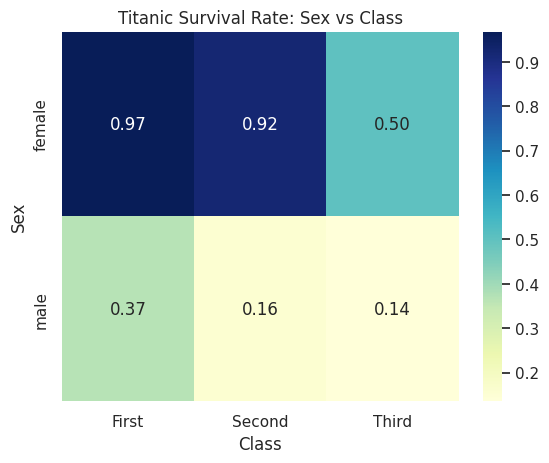

In [21]:
# Q6: How do we load Titanic and ask a survival question by class and sex using a heatmap?
titanic = sns.load_dataset('titanic')
survival_matrix = titanic.pivot_table(values='survived', index='sex', columns='class', aggfunc='mean')

sns.heatmap(survival_matrix, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Titanic Survival Rate: Sex vs Class')
plt.xlabel('Class')
plt.ylabel('Sex')
plt.show()

This heatmap converts a pivot table into a fast visual comparison of survival rates.
It is ideal for discussing why categorical combinations can influence outcomes.

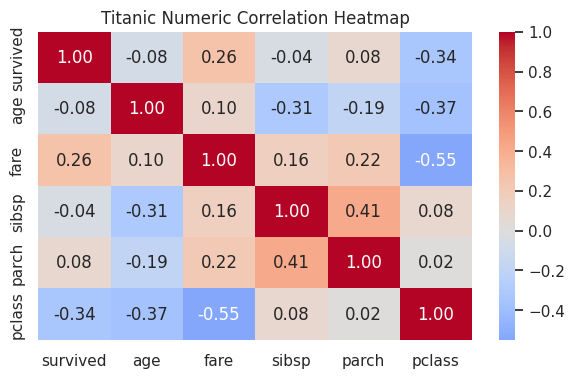

In [7]:
# Q7: Which numeric Titanic features move together, and how do we see that with a correlation heatmap?
num_cols = ['survived', 'age', 'fare', 'sibsp', 'parch', 'pclass']
corr = titanic[num_cols].corr(numeric_only=True)

plt.figure(figsize=(7, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Titanic Numeric Correlation Heatmap')
plt.show()

Correlation heatmaps are useful for spotting positive/negative relationships before modeling.
This helps students discuss feature interactions in a structured, data-backed way.

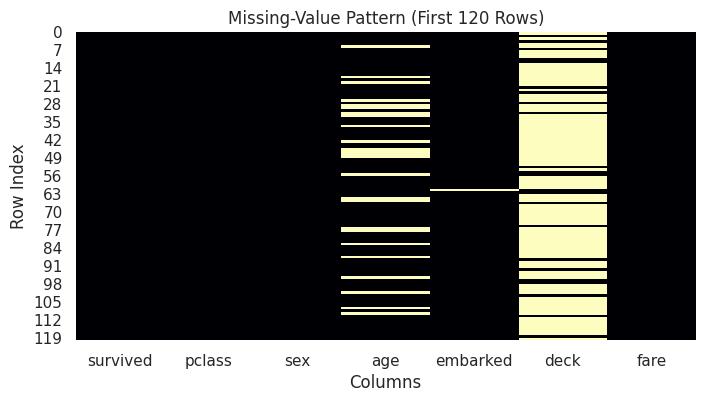

In [8]:
# Q8: Where is missing data concentrated in Titanic, and how do we visualize it as a heatmap?
missing_view = titanic[['survived', 'pclass', 'sex', 'age', 'embarked', 'deck', 'fare']].isnull().astype(int)

plt.figure(figsize=(8, 4))
sns.heatmap(missing_view.iloc[:120], cbar=False, cmap='magma')
plt.title('Missing-Value Pattern (First 120 Rows)')
plt.xlabel('Columns')
plt.ylabel('Row Index')
plt.show()

A missingness heatmap quickly reveals columns with frequent nulls and row-level patterns.
This supports practical cleaning decisions before feature engineering or model building.

In [24]:
# Q9 (File 1/3): How do we create a simple CSV file directly in notebook for practice?
simple_car_data = pd.DataFrame({
    'car_name': ['Swift', 'i20', 'City', 'Nexon', 'Creta', 'Amaze', 'Baleno', 'Venue'],
    'brand': ['Maruti', 'Hyundai', 'Honda', 'Tata', 'Hyundai', 'Honda', 'Maruti', 'Hyundai'],
    'fuel_type': ['Petrol', 'Petrol', 'Petrol', 'Diesel', 'Diesel', 'Petrol', 'CNG', 'Diesel'],
    'year': [2021, 2020, 2019, 2022, 2023, 2021, 2020, 2022],
    'price_lakh': [6.8, 7.9, 11.5, 9.4, 14.2, 8.6, 7.1, 12.9]
})

simple_car_data.to_csv('car_market_long.csv', index=False)
print(simple_car_data.shape)
print('Created file: car_market_long.csv')
print(simple_car_data)

(8, 5)
Created file: car_market_long.csv
  car_name    brand fuel_type  year  price_lakh
0    Swift   Maruti    Petrol  2021         6.8
1      i20  Hyundai    Petrol  2020         7.9
2     City    Honda    Petrol  2019        11.5
3    Nexon     Tata    Diesel  2022         9.4
4    Creta  Hyundai    Diesel  2023        14.2
5    Amaze    Honda    Petrol  2021         8.6
6   Baleno   Maruti       CNG  2020         7.1
7    Venue  Hyundai    Diesel  2022        12.9


This keeps file creation practical and beginner-friendly while still producing a reusable CSV.
Students can now clearly see how tabular data is written to disk before loading it in the next step.

Imported shape: (8, 5)
  car_name    brand fuel_type  year  price_lakh
0    Swift   Maruti    Petrol  2021         6.8
1      i20  Hyundai    Petrol  2020         7.9
2     City    Honda    Petrol  2019        11.5
3    Nexon     Tata    Diesel  2022         9.4
4    Creta  Hyundai    Diesel  2023        14.2


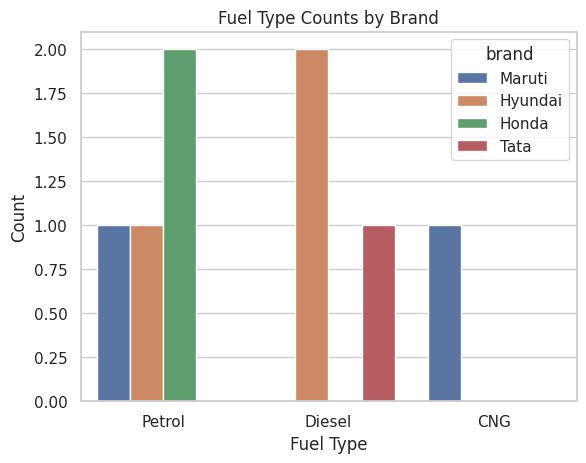

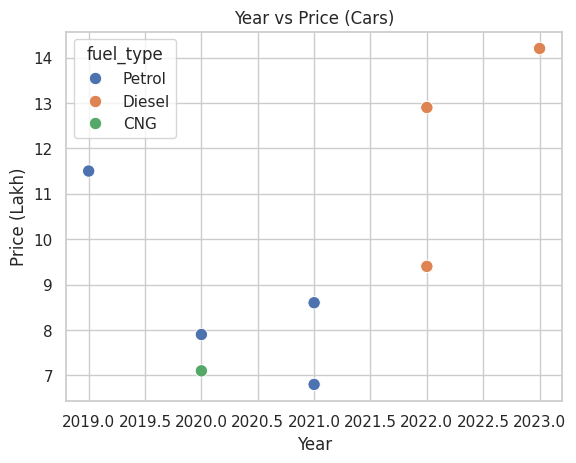

In [25]:
# Q10 (File 2/3 + Graph): How do we import the CSV and quickly visualize key patterns?
imported_cars = pd.read_csv('car_market_long.csv')

print('Imported shape:', imported_cars.shape)
print(imported_cars.head())


sns.countplot(data=imported_cars, x='fuel_type', hue='brand')
plt.title('Fuel Type Counts by Brand')
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.show()

sns.scatterplot(data=imported_cars, x='year', y='price_lakh', hue='fuel_type', s=80)
plt.title('Year vs Price (Cars)')
plt.xlabel('Year')
plt.ylabel('Price (Lakh)')
plt.show()

This step now combines file import and two simple visualizations for practical revision.
It adds more graph practice without making the logic heavy for classroom discussion.

In [29]:
# Q11 (File 3/3): How do we append records, save an updated file, and re-load it safely?
new_rows = pd.DataFrame([
    {'record_id': 121, 'car_name': 'Sonet', 'brand': 'Kia', 'fuel_type': 'Diesel', 'year': 2024, 'price_lakh': 13.4},
    {'record_id': 122, 'car_name': 'Altroz', 'brand': 'Tata', 'fuel_type': 'Petrol', 'year': 2023, 'km_driven': 12000, 'price_lakh': 9.7}
])

updated_cars = pd.concat([imported_cars, new_rows])
updated_cars.to_csv('car_market_long_updated.csv', index=False)
reloaded = pd.read_csv('car_market_long_updated.csv')

print('Updated rows:', len(reloaded))
print(reloaded)

Updated rows: 10
  car_name    brand fuel_type  year  price_lakh  record_id  km_driven
0    Swift   Maruti    Petrol  2021         6.8        NaN        NaN
1      i20  Hyundai    Petrol  2020         7.9        NaN        NaN
2     City    Honda    Petrol  2019        11.5        NaN        NaN
3    Nexon     Tata    Diesel  2022         9.4        NaN        NaN
4    Creta  Hyundai    Diesel  2023        14.2        NaN        NaN
5    Amaze    Honda    Petrol  2021         8.6        NaN        NaN
6   Baleno   Maruti       CNG  2020         7.1        NaN        NaN
7    Venue  Hyundai    Diesel  2022        12.9        NaN        NaN
8    Sonet      Kia    Diesel  2024        13.4      121.0        NaN
9   Altroz     Tata    Petrol  2023         9.7      122.0    12000.0


Appending and re-saving demonstrates real file manipulation rather than only in-memory analysis.
Re-reading verifies the save step, which is important in practical lab and viva settings.

## Part B: SQL Revision (Text Format for Programiz)
Run in: https://www.programiz.com/sql/online-compiler
Tables: Customers(customer_id, first_name, last_name, age, country), Orders(order_id, item, amount, customer_id), Shippings(shipping_id, status, customer).
Below are 5 SQL questions with plain-text queries (not code cells), from simple to moderate.

## Part C: Streamlit Quick Apps (run from terminal)
- Use the existing venv: `source .venv/bin/activate`
- Install (already done here): `pip install streamlit seaborn matplotlib`
- Save each code block to its own file (e.g., `app1.py`) then run `streamlit run app1.py`
- Keep files in the project root or a subfolder and run from that folder.

In [ ]:
# Q12: Minimal Streamlit home page with inputs and dynamic message
import streamlit as st

st.set_page_config(page_title="Hello Demo", page_icon="👋", layout="centered")
st.title("Hello from Streamlit")
name = st.text_input("Your name", "Ava")
mood = st.selectbox("How are you feeling?", ["Great", "Okay", "Tired"], index=0)
if name:
    st.success(f"Hi {name}, glad you're {mood} today!")
st.write("Tip: Save as app1.py and run: streamlit run app1.py")

Creates a minimal landing page with text input and selectbox and shows a friendly message.
Great starter app to verify Streamlit is installed and serving correctly.

In [ ]:
# Q13: Data table with sliders and filters (car prices)
import streamlit as st
import pandas as pd

st.set_page_config(page_title="Car Filter", layout="centered")
df = pd.DataFrame({
    "car": ["Swift","i20","City","Nexon","Creta","Amaze","Baleno","Venue"],
    "price_lakh": [6.8,7.9,11.5,9.4,14.2,8.6,7.1,12.9],
    "fuel": ["Petrol","Petrol","Petrol","Diesel","Diesel","Petrol","CNG","Diesel"],
    "year": [2021,2020,2019,2022,2023,2021,2020,2022]
})

price_max = st.slider("Max price (lakh)", 5.0, 16.0, 12.0, 0.1)
fuel_choice = st.multiselect("Fuel", options=sorted(df["fuel"].unique()), default=df["fuel"].unique())

filtered = df[(df["price_lakh"] <= price_max) & (df["fuel"].isin(fuel_choice))]
st.subheader("Filtered Cars")
st.dataframe(filtered)
st.bar_chart(filtered.set_index("car")["price_lakh"])

st.write("Save as app2.py and run: streamlit run app2.py")

Shows interactive filtering (slider + multiselect) and a quick bar chart for prices.
Good demo of widgets + dataframe + simple visualization in one page.

In [ ]:
# Q14: Quick plot from Titanic data (bar + heatmap)
import streamlit as st
import seaborn as sns
import matplotlib.pyplot as plt

st.set_page_config(page_title="Titanic Viz", layout="wide")
titanic = sns.load_dataset('titanic')

st.subheader("Survival counts by class")
fig1, ax1 = plt.subplots(figsize=(5,3))
sns.countplot(data=titanic, x='class', hue='survived', ax=ax1)
st.pyplot(fig1)

st.subheader("Survival rate heatmap (sex x class)")
rate = titanic.pivot_table(values='survived', index='sex', columns='class', aggfunc='mean')
fig2, ax2 = plt.subplots(figsize=(5,3))
sns.heatmap(rate, annot=True, fmt='.2f', cmap='YlGnBu', ax=ax2)
st.pyplot(fig2)

st.write("Save as app3.py and run: streamlit run app3.py")

Demonstrates Seaborn + Matplotlib inside Streamlit for bar and heatmap plots on Titanic data.
Good for showing both categorical breakdown and matrix-style survival rates.

### SQL 1 (Super Simple): Show all customers from USA
Query:
SELECT *
FROM Customers
WHERE country = 'USA';

### SQL 2 (Super Simple): Show all orders where amount is greater than 300
Query:
SELECT order_id, item, amount, customer_id
FROM Orders
WHERE amount > 300;

### SQL 3 (JOIN): Show customer name with item and amount
Query:
SELECT c.first_name, c.last_name, o.item, o.amount
FROM Customers c
INNER JOIN Orders o ON c.customer_id = o.customer_id;

### SQL 4 (HAVING): Show items ordered at least 2 times
Query:
SELECT item, COUNT(*) AS order_count
FROM Orders
GROUP BY item
HAVING COUNT(*) >= 2;

### SQL 5 (ORDER BY + JOIN): Show customers and their total spend, highest first
Query:
SELECT c.first_name, c.last_name, SUM(o.amount) AS total_spend
FROM Customers c
INNER JOIN Orders o ON c.customer_id = o.customer_id
GROUP BY c.first_name, c.last_name
ORDER BY total_spend DESC;

##DOUBTS

In [46]:
sen= "this is this is an example"
d = {}
words = sen.split()
for i in words:
  d[i]=words.count(i)
print(d)

#sen.count("this")

{'this': 2, 'is': 2, 'an': 1, 'example': 1}


In [43]:
sen = "this is this is an example"
d = {}
words = sen.split()
print(words)
for word in words:
    d[word] = words.count(word)

print(d)

['this', 'is', 'this', 'is', 'an', 'example']
{'this': 2, 'is': 2, 'an': 1, 'example': 1}


In [59]:
# Description
# Write a Python function called grade_summary(scores) that takes a list of integer scores (0-100) and:
# • Prints total students, average (rounded to 2dp), highest and lowest scores
# • Prints count of students who passed (>=60) and failed (<60)
# Example call: grade_summary 85, 42, 91, 58, 73, 36, 67])
# Expected output:
# Total students: 7
# Average score : 64.57
# Highest score : 91
# Lowest score : 36
# Passing (>=60) : 4
# Failing (<60): 3

egl = [85, 42, 91, 58, 73, 36, 67]

dl=[]
for i in egl:
  if i>=60:
    dl.append(i)



dl2=[]
for i in egl:
  if i<60:
    dl2.append(i)

print ("Total students: ", len(egl))
print ("Average score: ", round(sum(egl)/len(egl),2))
print("Highest score: ", max(egl))
print("Lowest score: ", min(egl))
print("Passing (>=60): ",len(dl))
print("Failing (<60): ",len(egl)-len(dl))
print("Failing (<60): ",len(dl2))

Total students:  7
Average score:  64.57
Highest score:  91
Lowest score:  36
Passing (>=60):  4
Failing (<60):  3
Failing (<60):  3


In [66]:
import numpy as np
arr = np.array([1,2,3,4,5,6,7,8])
np.mean(arr)
print(arr>5)
print(arr)


[False False False False False  True  True  True]
[1 2 3 4 5 6 7 8]
